# 04 — EDA and build modeling data

This notebook is the bridge between raw data collection and modeling.

It:

1. Audits the three raw datasets we trust.
2. Expands every GFS forecast from 186 native lead times to the required **336 hourly lead times**.
3. Joins historical GFS forecasts to actual RDU temperatures.
4. Builds leakage-safe features using only information that would have been available before each simulated forecast period.
5. Performs EDA on the development years.
6. Saves clean historical and future modeling tables.

## Raw inputs

Only these files are used:

- `data/raw/RDU_ACTUAL_HISTORICAL.csv`
- `data/raw/NOAA_GFS_FORECAST_HISTORICAL_FAST.csv`
- `data/raw/NOAA_GFS_FORECAST_FUTURE_FAST.csv`

## Locked modeling split

- **2021–2023:** training
- **2024:** validation / tuning
- **2025:** final historical test
- **2026:** assignment forecast

To preserve the 2025 test set, EDA involving forecast **errors** uses only 2021–2024. We inspect 2025 for coverage, but we do not report its error performance here.

## Leakage rule for observed-temperature features

For each GFS run:

`simulated cutoff = GFS initialization + 10 hours`

Observed-temperature features use only RDU measurements strictly **before** that cutoff.

## Outputs

- `data/processed/modeling_historical.csv`
- `data/processed/modeling_future.csv`
- `data/processed/modeling_feature_manifest.json`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

## 1. Locate the project and load raw data

In [2]:
def find_project_root():
    """Find a nearby directory containing data/raw."""
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find a project root containing data/raw. "
        "Run this notebook from the project repo or notebooks/ directory."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ACTUAL_PATH = RAW_DIR / "RDU_ACTUAL_HISTORICAL.csv"
HIST_GFS_PATH = RAW_DIR / "NOAA_GFS_FORECAST_HISTORICAL_FAST.csv"
FUTURE_GFS_PATH = RAW_DIR / "NOAA_GFS_FORECAST_FUTURE_FAST.csv"

for path in [ACTUAL_PATH, HIST_GFS_PATH, FUTURE_GFS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required raw dataset not found: {path}")

print("Project root:", PROJECT_ROOT)
print("Raw directory:", RAW_DIR)
print("Processed directory:", PROCESSED_DIR)

Project root: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU
Raw directory: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/raw
Processed directory: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed


In [3]:
actual_raw = pd.read_csv(ACTUAL_PATH, low_memory=False)
hist_gfs_raw = pd.read_csv(HIST_GFS_PATH)
future_gfs_raw = pd.read_csv(FUTURE_GFS_PATH)

print("RDU actuals:", actual_raw.shape)
print("Historical GFS:", hist_gfs_raw.shape)
print("Future GFS:", future_gfs_raw.shape)

RDU actuals: (93769, 30)
Historical GFS: (7440, 27)
Future GFS: (186, 27)


## 2. Schema and structural audit

In [4]:
REQUIRED_ACTUAL_COLUMNS = {
    "observation_time_utc",
    "hour_utc",
    "temperature_f",
}

REQUIRED_GFS_COLUMNS = {
    "gfs_init_utc",
    "forecast_hour",
    "valid_time_utc",
    "gfs_temp_c",
    "gfs_temp_f",
    "gfs_relative_humidity_pct",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_mslp_pa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_kg_m2_s",
    "gfs_grid_lat",
    "gfs_grid_lon",
    "data_product_version",
}


def assert_required_columns(df, required, name):
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


assert_required_columns(actual_raw, REQUIRED_ACTUAL_COLUMNS, "RDU actuals")
assert_required_columns(hist_gfs_raw, REQUIRED_GFS_COLUMNS, "Historical GFS")
assert_required_columns(future_gfs_raw, REQUIRED_GFS_COLUMNS, "Future GFS")

print("PASS: required columns are present.")

PASS: required columns are present.


In [5]:
actual = actual_raw.copy()
actual["observation_time_utc"] = pd.to_datetime(
    actual["observation_time_utc"], utc=True
)
actual["hour_utc"] = pd.to_datetime(
    actual["hour_utc"], utc=True
)
actual = actual.sort_values("hour_utc").reset_index(drop=True)


def prepare_gfs(df):
    out = df.copy()

    out["gfs_init_utc"] = pd.to_datetime(out["gfs_init_utc"], utc=True)
    out["valid_time_utc"] = pd.to_datetime(out["valid_time_utc"], utc=True)
    out["forecast_hour"] = pd.to_numeric(
        out["forecast_hour"], errors="raise"
    ).astype(int)

    return (
        out
        .sort_values(["gfs_init_utc", "forecast_hour"])
        .reset_index(drop=True)
    )


hist_gfs = prepare_gfs(hist_gfs_raw)
future_gfs = prepare_gfs(future_gfs_raw)

In [6]:
audit = pd.DataFrame([
    {
        "dataset": "RDU actuals",
        "rows": len(actual),
        "duplicate_keys": actual["hour_utc"].duplicated().sum(),
        "missing_temperature": actual["temperature_f"].isna().sum(),
        "min_time": actual["hour_utc"].min(),
        "max_time": actual["hour_utc"].max(),
    },
    {
        "dataset": "Historical GFS",
        "rows": len(hist_gfs),
        "duplicate_keys": hist_gfs.duplicated(
            ["gfs_init_utc", "forecast_hour"]
        ).sum(),
        "missing_temperature": hist_gfs["gfs_temp_f"].isna().sum(),
        "min_time": hist_gfs["valid_time_utc"].min(),
        "max_time": hist_gfs["valid_time_utc"].max(),
    },
    {
        "dataset": "Future GFS",
        "rows": len(future_gfs),
        "duplicate_keys": future_gfs.duplicated(
            ["gfs_init_utc", "forecast_hour"]
        ).sum(),
        "missing_temperature": future_gfs["gfs_temp_f"].isna().sum(),
        "min_time": future_gfs["valid_time_utc"].min(),
        "max_time": future_gfs["valid_time_utc"].max(),
    },
])

display(audit)

assert actual["hour_utc"].duplicated().sum() == 0
assert hist_gfs.duplicated(["gfs_init_utc", "forecast_hour"]).sum() == 0
assert future_gfs.duplicated(["gfs_init_utc", "forecast_hour"]).sum() == 0

assert hist_gfs["gfs_init_utc"].nunique() == 40
assert future_gfs["gfs_init_utc"].nunique() == 1
assert set(hist_gfs.groupby("gfs_init_utc").size().unique()) == {186}
assert len(future_gfs) == 186

print("PASS: raw structural checks succeeded.")

,dataset,rows,duplicate_keys,missing_temperature,min_time,max_time
0,RDU actuals,93769,0,32,2016-01-01 05:00:00+00:00,2026-09-17 03:00:00+00:00
1,Historical GFS,7440,0,0,2021-07-30 04:00:00+00:00,2025-10-01 03:00:00+00:00
2,Future GFS,186,0,0,2026-09-17 04:00:00+00:00,2026-10-01 03:00:00+00:00


PASS: raw structural checks succeeded.


### Actual-temperature coverage

This is a source-quality audit only. Missing target temperatures are preserved rather than fabricated.

In [7]:
actual["year"] = actual["hour_utc"].dt.year

actual_coverage_by_year = (
    actual
    .groupby("year")
    .agg(
        rows=("hour_utc", "size"),
        temperature_present=("temperature_f", lambda s: s.notna().sum()),
        temperature_missing=("temperature_f", lambda s: s.isna().sum()),
    )
)

actual_coverage_by_year["temperature_coverage_pct"] = (
    100
    * actual_coverage_by_year["temperature_present"]
    / actual_coverage_by_year["rows"]
)

display(actual_coverage_by_year.round(3))

,rows,temperature_present,temperature_missing,temperature_coverage_pct
year,,,,
2016,8779,8779,0,100.000
2017,8760,8760,0,100.000
2018,8760,8760,0,100.000
2019,8760,8760,0,100.000
2020,8784,8784,0,100.000
2021,8759,8759,0,100.000
2022,8760,8760,0,100.000
2023,8760,8760,0,100.000
2024,8784,8784,0,100.000


In [8]:
expected_actual_hours = pd.date_range(
    start=actual["hour_utc"].min(),
    end=actual["hour_utc"].max(),
    freq="h",
)

observed_hours = pd.DatetimeIndex(actual["hour_utc"].dropna().unique())
missing_clock_hours = expected_actual_hours.difference(observed_hours)

print("Missing clock hours:", len(missing_clock_hours))
print("Rows present but temperature is NaN:", actual["temperature_f"].isna().sum())

if len(missing_clock_hours):
    print("\nFirst 20 missing clock hours:")
    print(missing_clock_hours[:20])

Missing clock hours: 118
Rows present but temperature is NaN: 32

First 20 missing clock hours:
DatetimeIndex(['2021-03-27 07:00:00+00:00', '2025-01-23 07:00:00+00:00',
               '2025-01-23 08:00:00+00:00', '2025-01-23 09:00:00+00:00',
               '2025-03-10 04:00:00+00:00', '2025-03-21 10:00:00+00:00',
               '2025-03-29 02:00:00+00:00', '2025-03-29 03:00:00+00:00',
               '2025-03-29 04:00:00+00:00', '2025-03-29 05:00:00+00:00',
               '2025-05-04 13:00:00+00:00', '2025-05-06 01:00:00+00:00',
               '2025-08-29 23:00:00+00:00', '2025-08-30 00:00:00+00:00',
               '2025-08-30 01:00:00+00:00', '2025-08-30 02:00:00+00:00',
               '2025-08-30 03:00:00+00:00', '2025-08-30 04:00:00+00:00',
               '2025-08-30 05:00:00+00:00', '2025-08-30 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


## 3. Expand every GFS run to all 336 required hours

GFS is hourly through F120 and every 3 hours afterward.

We create every integer forecast hour from **F010 through F345**. For non-native hours after F120, we linearly interpolate only the primitive variables:

- temperature
- relative humidity
- U wind
- V wind
- pressure
- cloud cover
- precipitation rate

Dew point, wind speed, and wind direction are calculated only **after** interpolation.

In [9]:
TARGET_START_LEAD = 10
TARGET_END_LEAD = 345

DESIRED_FORECAST_HOURS = np.arange(
    TARGET_START_LEAD,
    TARGET_END_LEAD + 1
)

assert len(DESIRED_FORECAST_HOURS) == 336

PRIMITIVE_GFS_COLUMNS = [
    "gfs_temp_c",
    "gfs_relative_humidity_pct",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_mslp_pa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_kg_m2_s",
]

In [10]:
def expand_gfs_hourly(df):
    expanded_runs = []

    for init_time, run in df.groupby("gfs_init_utc", sort=True):
        run = run.sort_values("forecast_hour").copy()

        native_hours = run["forecast_hour"].to_numpy(dtype=float)

        if native_hours.min() > TARGET_START_LEAD:
            raise ValueError(f"Run {init_time} starts too late.")

        if native_hours.max() < TARGET_END_LEAD:
            raise ValueError(f"Run {init_time} ends too early.")

        expanded = pd.DataFrame({
            "forecast_hour": DESIRED_FORECAST_HOURS
        })

        for column in PRIMITIVE_GFS_COLUMNS:
            values = pd.to_numeric(
                run[column], errors="raise"
            ).to_numpy(dtype=float)

            expanded[column] = np.interp(
                DESIRED_FORECAST_HOURS,
                native_hours,
                values,
            )

        expanded["is_native_gfs_time"] = np.isin(
            DESIRED_FORECAST_HOURS,
            native_hours,
        ).astype(int)

        expanded["gfs_init_utc"] = init_time

        expanded["valid_time_utc"] = (
            init_time
            + pd.to_timedelta(expanded["forecast_hour"], unit="h")
        )

        expanded["valid_time_local"] = (
            expanded["valid_time_utc"]
            .dt.tz_convert("America/New_York")
        )

        expanded["gfs_grid_lat"] = run["gfs_grid_lat"].iloc[0]
        expanded["gfs_grid_lon"] = run["gfs_grid_lon"].iloc[0]
        expanded["data_product_version"] = run[
            "data_product_version"
        ].iloc[0]

        expanded_runs.append(expanded)

    result = pd.concat(expanded_runs, ignore_index=True)

    return (
        result
        .sort_values(["gfs_init_utc", "forecast_hour"])
        .reset_index(drop=True)
    )


hist_hourly = expand_gfs_hourly(hist_gfs)
future_hourly = expand_gfs_hourly(future_gfs)

print("Historical hourly:", hist_hourly.shape)
print("Future hourly:", future_hourly.shape)

assert len(hist_hourly) == 40 * 336
assert len(future_hourly) == 336

Historical hourly: (13440, 15)
Future hourly: (336, 15)


### Verify interpolation leaves native GFS temperature unchanged

In [11]:
native_check = (
    hist_hourly[
        hist_hourly["is_native_gfs_time"] == 1
    ]
    .merge(
        hist_gfs[
            [
                "gfs_init_utc",
                "forecast_hour",
                "gfs_temp_c",
            ]
        ],
        on=["gfs_init_utc", "forecast_hour"],
        how="inner",
        validate="one_to_one",
        suffixes=("_expanded", "_raw"),
    )
)

native_check["abs_diff_c"] = (
    native_check["gfs_temp_c_expanded"]
    - native_check["gfs_temp_c_raw"]
).abs()

print(
    "Maximum temperature difference at native lead times:",
    native_check["abs_diff_c"].max(),
    "°C",
)

assert native_check["abs_diff_c"].max() < 1e-10
print("PASS: native GFS values are unchanged.")

Maximum temperature difference at native lead times: 0.0 °C
PASS: native GFS values are unchanged.


### Visualize one run before and after interpolation

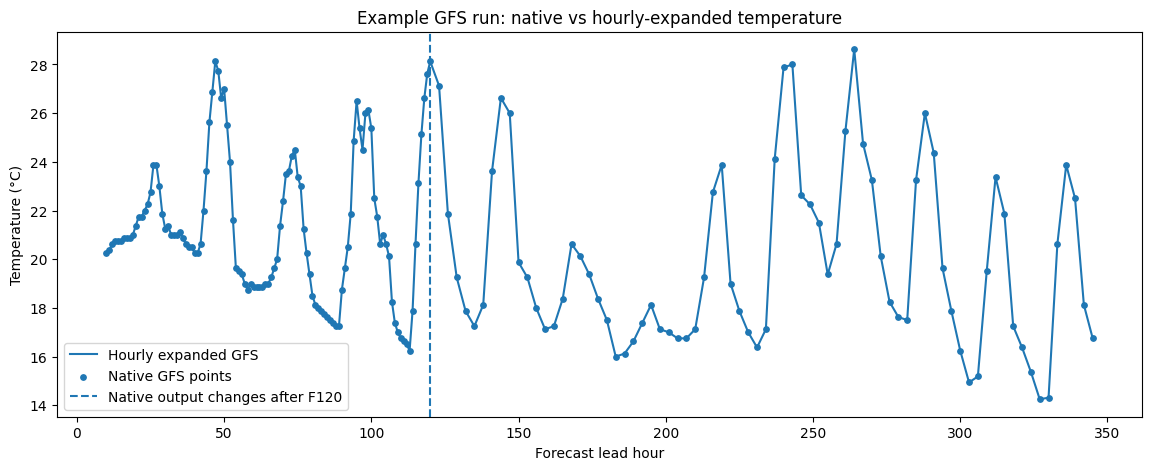

In [12]:
example_init = pd.Timestamp("2024-09-16 18:00:00", tz="UTC")

example_raw = hist_gfs[
    hist_gfs["gfs_init_utc"] == example_init
]

example_expanded = hist_hourly[
    hist_hourly["gfs_init_utc"] == example_init
]

plt.figure(figsize=(14, 5))

plt.plot(
    example_expanded["forecast_hour"],
    example_expanded["gfs_temp_c"],
    label="Hourly expanded GFS",
)

plt.scatter(
    example_raw["forecast_hour"],
    example_raw["gfs_temp_c"],
    s=15,
    label="Native GFS points",
)

plt.axvline(
    120,
    linestyle="--",
    label="Native output changes after F120",
)

plt.title("Example GFS run: native vs hourly-expanded temperature")
plt.xlabel("Forecast lead hour")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

## 4. Derive meteorological features after interpolation

In [13]:
def add_derived_gfs_features(df):
    out = df.copy()

    out["gfs_temp_f"] = (
        out["gfs_temp_c"] * 9.0 / 5.0 + 32.0
    )

    rh = out["gfs_relative_humidity_pct"].clip(0.1, 100.0)

    a = 17.625
    b = 243.04

    gamma = (
        np.log(rh / 100.0)
        + (
            a * out["gfs_temp_c"]
            / (b + out["gfs_temp_c"])
        )
    )

    out["gfs_dewpoint_c"] = b * gamma / (a - gamma)
    out["gfs_dewpoint_f"] = (
        out["gfs_dewpoint_c"] * 9.0 / 5.0 + 32.0
    )

    out["gfs_dewpoint_depression_f"] = (
        out["gfs_temp_f"]
        - out["gfs_dewpoint_f"]
    )

    out["gfs_wind_speed_mps"] = np.sqrt(
        out["gfs_u10_mps"] ** 2
        + out["gfs_v10_mps"] ** 2
    )

    out["gfs_wind_speed_mph"] = (
        out["gfs_wind_speed_mps"]
        * 2.2369362920544
    )

    out["gfs_wind_direction_deg"] = (
        270.0
        - np.degrees(
            np.arctan2(
                out["gfs_v10_mps"],
                out["gfs_u10_mps"],
            )
        )
    ) % 360.0

    wind_radians = np.deg2rad(
        out["gfs_wind_direction_deg"]
    )

    out["gfs_wind_dir_sin"] = np.sin(wind_radians)
    out["gfs_wind_dir_cos"] = np.cos(wind_radians)

    out["gfs_mslp_hpa"] = out["gfs_mslp_pa"] / 100.0

    out["gfs_precip_rate_mm_hr"] = (
        out["gfs_precip_rate_kg_m2_s"]
        * 3600.0
    )

    return out


hist_hourly = add_derived_gfs_features(hist_hourly)
future_hourly = add_derived_gfs_features(future_hourly)

## 5. Join historical forecasts to actual RDU temperatures

In [14]:
actual_labels = (
    actual[
        [
            "hour_utc",
            "temperature_f",
        ]
    ]
    .rename(
        columns={
            "hour_utc": "valid_time_utc",
            "temperature_f": "actual_temp_f",
        }
    )
)

historical = hist_hourly.merge(
    actual_labels,
    on="valid_time_utc",
    how="left",
    validate="many_to_one",
)

print("Total historical hourly forecast rows:", len(historical))
print(
    "Rows with actual-temperature target:",
    historical["actual_temp_f"].notna().sum(),
)
print(
    "Rows without target:",
    historical["actual_temp_f"].isna().sum(),
)

display(
    historical[
        historical["actual_temp_f"].isna()
    ][
        [
            "gfs_init_utc",
            "forecast_hour",
            "valid_time_utc",
        ]
    ].head(20)
)

Total historical hourly forecast rows: 13440
Rows with actual-temperature target: 13237
Rows without target: 203


,gfs_init_utc,forecast_hour,valid_time_utc
11995,2025-08-19 18:00:00+00:00,245,2025-08-29 23:00:00+00:00
11996,2025-08-19 18:00:00+00:00,246,2025-08-30 00:00:00+00:00
11997,2025-08-19 18:00:00+00:00,247,2025-08-30 01:00:00+00:00
11998,2025-08-19 18:00:00+00:00,248,2025-08-30 02:00:00+00:00
11999,2025-08-19 18:00:00+00:00,249,2025-08-30 03:00:00+00:00
12000,2025-08-19 18:00:00+00:00,250,2025-08-30 04:00:00+00:00
12001,2025-08-19 18:00:00+00:00,251,2025-08-30 05:00:00+00:00
12002,2025-08-19 18:00:00+00:00,252,2025-08-30 06:00:00+00:00
12003,2025-08-19 18:00:00+00:00,253,2025-08-30 07:00:00+00:00
12004,2025-08-19 18:00:00+00:00,254,2025-08-30 08:00:00+00:00


We do **not** interpolate missing target temperatures. Those rows are excluded from the final supervised-learning table.

## 6. Add leakage-safe recent-observation features

For each run, the simulated forecast cutoff is `GFS initialization + 10 hours`.

Only actual RDU measurements strictly before that cutoff can contribute to the following features.

In [15]:
actual_for_features = (
    actual[
        [
            "observation_time_utc",
            "hour_utc",
            "temperature_f",
        ]
    ]
    .dropna(
        subset=[
            "observation_time_utc",
            "temperature_f",
        ]
    )
    .sort_values("observation_time_utc")
    .reset_index(drop=True)
)


def recent_observation_features(init_time):
    simulated_cutoff = (
        init_time
        + pd.Timedelta(hours=TARGET_START_LEAD)
    )

    eligible = actual_for_features[
        actual_for_features[
            "observation_time_utc"
        ] < simulated_cutoff
    ]

    if len(eligible) == 0:
        raise RuntimeError(
            f"No eligible actual observations before {simulated_cutoff}."
        )

    last_row = eligible.iloc[-1]

    features = {
        "simulated_cutoff_utc": simulated_cutoff,
        "recent_actual_temp_f": float(last_row["temperature_f"]),
        "recent_obs_age_hours": (
            simulated_cutoff
            - last_row["observation_time_utc"]
        ).total_seconds() / 3600.0,
    }

    for hours in [6, 24]:
        start_time = (
            simulated_cutoff
            - pd.Timedelta(hours=hours)
        )

        window = eligible[
            eligible["observation_time_utc"] >= start_time
        ]

        values = (
            window["temperature_f"]
            .dropna()
            .astype(float)
        )

        prefix = f"recent_{hours}h"

        features[f"{prefix}_mean_f"] = values.mean()
        features[f"{prefix}_std_f"] = values.std(ddof=0)

        if len(values) >= 2:
            features[f"{prefix}_change_f"] = (
                values.iloc[-1] - values.iloc[0]
            )
        else:
            features[f"{prefix}_change_f"] = np.nan

        if hours == 24:
            features["recent_24h_min_f"] = values.min()
            features["recent_24h_max_f"] = values.max()
            features["recent_24h_range_f"] = (
                values.max() - values.min()
            )

    return features


all_run_inits = sorted(
    set(historical["gfs_init_utc"].unique())
    | set(future_hourly["gfs_init_utc"].unique())
)

origin_feature_rows = []

for init_time in all_run_inits:
    origin_feature_rows.append({
        "gfs_init_utc": init_time,
        **recent_observation_features(pd.Timestamp(init_time)),
    })

origin_features = pd.DataFrame(origin_feature_rows)

display(origin_features.head())

,gfs_init_utc,simulated_cutoff_utc,recent_actual_temp_f,recent_obs_age_hours,recent_6h_mean_f,recent_6h_std_f,recent_6h_change_f,recent_24h_mean_f,recent_24h_std_f,recent_24h_change_f,recent_24h_min_f,recent_24h_max_f,recent_24h_range_f
0,2021-07-29 18:00:00+00:00,2021-07-30 04:00:00+00:00,82.04,0.15,85.49,2.799018,-7.92,81.5000,8.884053,10.98,69.08,93.02,23.94
1,2021-08-05 18:00:00+00:00,2021-08-06 04:00:00+00:00,69.98,0.15,74.96,4.819461,-12.96,74.2250,7.603432,0.00,62.96,84.92,21.96
2,2021-08-12 18:00:00+00:00,2021-08-13 04:00:00+00:00,82.04,0.15,85.49,2.629924,-7.92,84.5900,7.160454,3.06,73.94,96.08,22.14
3,2021-08-19 18:00:00+00:00,2021-08-20 04:00:00+00:00,73.04,0.15,82.49,5.394747,-18.00,83.0000,7.001450,-3.96,73.04,93.02,19.98
4,2021-08-26 18:00:00+00:00,2021-08-27 04:00:00+00:00,78.98,0.15,82.19,2.696831,-8.10,82.2575,6.076384,3.06,73.94,91.94,18.00


In [16]:
RECENT_FEATURE_COLUMNS = [
    "recent_actual_temp_f",
    "recent_obs_age_hours",
    "recent_6h_mean_f",
    "recent_6h_std_f",
    "recent_6h_change_f",
    "recent_24h_mean_f",
    "recent_24h_std_f",
    "recent_24h_change_f",
    "recent_24h_min_f",
    "recent_24h_max_f",
    "recent_24h_range_f",
]

if origin_features[RECENT_FEATURE_COLUMNS].isna().any().any():
    display(
        origin_features[
            origin_features[
                RECENT_FEATURE_COLUMNS
            ].isna().any(axis=1)
        ]
    )

    raise RuntimeError(
        "At least one forecast run is missing a recent-observation feature."
    )

print("PASS: every run has complete recent-observation features.")

PASS: every run has complete recent-observation features.


In [17]:
historical = historical.merge(
    origin_features,
    on="gfs_init_utc",
    how="left",
    validate="many_to_one",
)

future = future_hourly.merge(
    origin_features,
    on="gfs_init_utc",
    how="left",
    validate="many_to_one",
)

## 7. Add calendar and forecast-horizon features

In [18]:
def add_time_features(df):
    out = df.copy()

    local_time = (
        pd.to_datetime(out["valid_time_utc"], utc=True)
        .dt.tz_convert("America/New_York")
    )

    out["local_hour"] = local_time.dt.hour
    out["day_of_year"] = local_time.dt.dayofyear

    out["hour_sin"] = np.sin(
        2.0 * np.pi * out["local_hour"] / 24.0
    )
    out["hour_cos"] = np.cos(
        2.0 * np.pi * out["local_hour"] / 24.0
    )

    out["doy_sin"] = np.sin(
        2.0 * np.pi * out["day_of_year"] / 365.25
    )
    out["doy_cos"] = np.cos(
        2.0 * np.pi * out["day_of_year"] / 365.25
    )

    out["hours_into_target"] = (
        out["forecast_hour"] - TARGET_START_LEAD
    )

    out["target_day"] = (
        out["hours_into_target"] // 24 + 1
    ).astype(int)

    out["forecast_year"] = out["gfs_init_utc"].dt.year

    out["gfs_temp_minus_recent_actual_f"] = (
        out["gfs_temp_f"]
        - out["recent_actual_temp_f"]
    )

    return out


historical = add_time_features(historical)
future = add_time_features(future)

In [19]:
def assign_split(year):
    if year in [2021, 2022, 2023]:
        return "train"
    if year == 2024:
        return "validation"
    if year == 2025:
        return "test"
    if year == 2026:
        return "forecast_2026"
    return "other"


historical["split"] = historical["forecast_year"].map(assign_split)
future["split"] = "forecast_2026"

print(historical["split"].value_counts())
print("\nFuture split:")
print(future["split"].value_counts())

split
train         8064
validation    2688
test          2688
Name: count, dtype: int64

Future split:
split
forecast_2026    336
Name: count, dtype: int64


## 8. EDA: target coverage by split and forecast run

In [20]:
coverage_by_split = (
    historical
    .groupby("split")
    .agg(
        rows=("actual_temp_f", "size"),
        labeled_rows=("actual_temp_f", lambda s: s.notna().sum()),
        missing_targets=("actual_temp_f", lambda s: s.isna().sum()),
    )
)

coverage_by_split["target_coverage_pct"] = (
    100
    * coverage_by_split["labeled_rows"]
    / coverage_by_split["rows"]
)

display(coverage_by_split.round(3))

,rows,labeled_rows,missing_targets,target_coverage_pct
split,,,,
test,2688,2485,203,92.448
train,8064,8064,0,100.000
validation,2688,2688,0,100.000


In [21]:
coverage_by_run = (
    historical
    .groupby("gfs_init_utc")
    .agg(
        rows=("actual_temp_f", "size"),
        labeled_rows=("actual_temp_f", lambda s: s.notna().sum()),
    )
)

coverage_by_run["missing_targets"] = (
    coverage_by_run["rows"]
    - coverage_by_run["labeled_rows"]
)

display(
    coverage_by_run[
        coverage_by_run["missing_targets"] > 0
    ]
)

print(
    "\nCoverage only: no 2025 forecast-error metric is calculated here."
)

,rows,labeled_rows,missing_targets
gfs_init_utc,,,
2025-08-19 18:00:00+00:00,336,243,93
2025-08-26 18:00:00+00:00,336,238,98
2025-09-02 18:00:00+00:00,336,328,8
2025-09-09 18:00:00+00:00,336,333,3
2025-09-16 18:00:00+00:00,336,335,1



Coverage only: no 2025 forecast-error metric is calculated here.


## 9. EDA: raw-GFS baseline on development data only

The raw GFS temperature is our main baseline.

**Development data = 2021–2024 only.**  
The 2025 targets remain excluded from error analysis.

In [22]:
dev = historical[
    historical["split"].isin(["train", "validation"])
    & historical["actual_temp_f"].notna()
].copy()

dev["gfs_error_f"] = (
    dev["gfs_temp_f"] - dev["actual_temp_f"]
)
dev["gfs_abs_error_f"] = dev["gfs_error_f"].abs()
dev["gfs_squared_error_f2"] = dev["gfs_error_f"] ** 2


def regression_metrics(frame):
    error = frame["gfs_temp_f"] - frame["actual_temp_f"]

    return pd.Series({
        "n": len(frame),
        "MAE_F": error.abs().mean(),
        "RMSE_F": np.sqrt(np.mean(error ** 2)),
        "Bias_F": error.mean(),
    })


development_baseline = (
    dev
    .groupby("split")
    .apply(regression_metrics, include_groups=False)
)

display(development_baseline.round(3))

,n,MAE_F,RMSE_F,Bias_F
split,,,,
train,8064.0,4.699,6.341,-0.622
validation,2688.0,4.907,6.363,-1.497


### Error versus forecast horizon

In [23]:
HORIZON_BINS = [9, 72, 168, 345]
HORIZON_LABELS = [
    "10–72 h",
    "73–168 h",
    "169–345 h",
]

dev["horizon_group"] = pd.cut(
    dev["forecast_hour"],
    bins=HORIZON_BINS,
    labels=HORIZON_LABELS,
)

horizon_metrics = (
    dev
    .groupby("horizon_group", observed=True)
    .apply(regression_metrics, include_groups=False)
)

display(horizon_metrics.round(3))

,n,MAE_F,RMSE_F,Bias_F
horizon_group,,,,
10–72 h,2016.0,3.122,3.993,-1.146
73–168 h,3072.0,4.075,5.305,-1.152
169–345 h,5664.0,5.697,7.451,-0.564


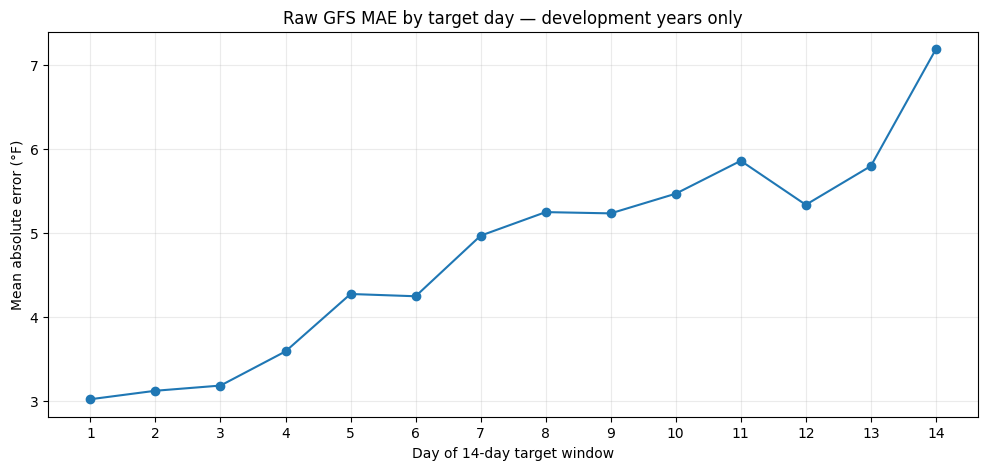

In [24]:
mae_by_target_day = (
    dev
    .groupby("target_day")["gfs_abs_error_f"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    mae_by_target_day.index,
    mae_by_target_day.values,
    marker="o",
)

plt.title("Raw GFS MAE by target day — development years only")
plt.xlabel("Day of 14-day target window")
plt.ylabel("Mean absolute error (°F)")
plt.xticks(range(1, 15))
plt.grid(alpha=0.25)
plt.show()

### Error versus local hour

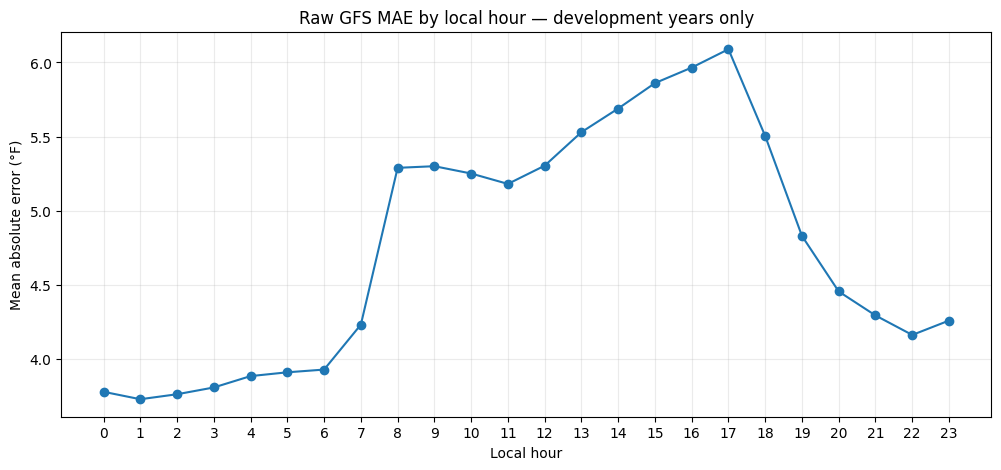

,MAE_F,Bias_F
local_hour,,
0,3.781,-0.730
1,3.731,-0.848
2,3.764,-0.854
3,3.810,-0.861
4,3.886,-0.934
5,3.912,-1.042
6,3.930,-0.701
7,4.233,-2.379
8,5.290,-4.545


In [25]:
mae_by_hour = (
    dev
    .groupby("local_hour")["gfs_abs_error_f"]
    .mean()
)

bias_by_hour = (
    dev
    .groupby("local_hour")["gfs_error_f"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    mae_by_hour.index,
    mae_by_hour.values,
    marker="o",
)

plt.title("Raw GFS MAE by local hour — development years only")
plt.xlabel("Local hour")
plt.ylabel("Mean absolute error (°F)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.25)
plt.show()

display(
    pd.DataFrame({
        "MAE_F": mae_by_hour,
        "Bias_F": bias_by_hour,
    }).round(3)
)

### Predicted versus actual temperature

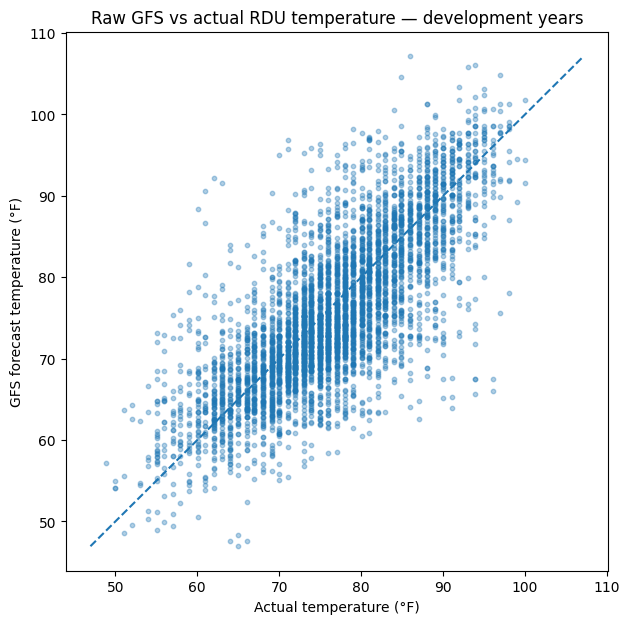

In [26]:
scatter_sample = dev.sample(
    n=min(5000, len(dev)),
    random_state=42,
)

plot_min = min(
    scatter_sample["actual_temp_f"].min(),
    scatter_sample["gfs_temp_f"].min(),
)

plot_max = max(
    scatter_sample["actual_temp_f"].max(),
    scatter_sample["gfs_temp_f"].max(),
)

plt.figure(figsize=(7, 7))

plt.scatter(
    scatter_sample["actual_temp_f"],
    scatter_sample["gfs_temp_f"],
    s=10,
    alpha=0.35,
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

plt.title("Raw GFS vs actual RDU temperature — development years")
plt.xlabel("Actual temperature (°F)")
plt.ylabel("GFS forecast temperature (°F)")
plt.show()

### Relationships between weather state and GFS error

In [27]:
candidate_error_relationships = [
    "forecast_hour",
    "local_hour",
    "gfs_relative_humidity_pct",
    "gfs_dewpoint_f",
    "gfs_wind_speed_mph",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",
    "gfs_dewpoint_depression_f",
]

correlations = (
    dev[
        [
            "gfs_error_f",
            *candidate_error_relationships,
        ]
    ]
    .corr(numeric_only=True)["gfs_error_f"]
    .drop("gfs_error_f")
    .sort_values(
        key=lambda s: s.abs(),
        ascending=False,
    )
)

display(
    correlations.to_frame(
        "correlation_with_GFS_error"
    ).round(3)
)

,correlation_with_GFS_error
gfs_dewpoint_depression_f,0.404
gfs_relative_humidity_pct,-0.390
gfs_precip_rate_mm_hr,-0.181
gfs_total_cloud_cover_pct,-0.180
gfs_mslp_hpa,-0.136
local_hour,0.108
forecast_hour,0.087
gfs_wind_speed_mph,-0.031
gfs_dewpoint_f,0.020


Correlation is descriptive, not a feature-selection rule. We will judge features by chronological validation in the modeling notebooks.

## 10. Define the modeling feature set

In [28]:
MODEL_FEATURES = [
    # Core GFS temperature.
    "gfs_temp_f",

    # GFS atmospheric state.
    "gfs_relative_humidity_pct",
    "gfs_dewpoint_f",
    "gfs_dewpoint_depression_f",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_wind_speed_mph",
    "gfs_wind_dir_sin",
    "gfs_wind_dir_cos",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",

    # Forecast horizon / interpolation.
    "forecast_hour",
    "hours_into_target",
    "target_day",
    "is_native_gfs_time",

    # Known calendar information.
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    # Actual RDU observations available before the simulated cutoff.
    "recent_actual_temp_f",
    "recent_obs_age_hours",
    "recent_6h_mean_f",
    "recent_6h_std_f",
    "recent_6h_change_f",
    "recent_24h_mean_f",
    "recent_24h_std_f",
    "recent_24h_change_f",
    "recent_24h_min_f",
    "recent_24h_max_f",
    "recent_24h_range_f",

    # Relation between GFS target temperature and current local state.
    "gfs_temp_minus_recent_actual_f",
]

TARGET_COLUMN = "actual_temp_f"

METADATA_COLUMNS = [
    "gfs_init_utc",
    "valid_time_utc",
    "valid_time_local",
    "forecast_year",
    "split",
    "local_hour",
    "day_of_year",
    "gfs_grid_lat",
    "gfs_grid_lon",
    "data_product_version",
    "simulated_cutoff_utc",
]

## 11. Historical/future feature symmetry and missingness

In [29]:
missing_hist_features = sorted(
    set(MODEL_FEATURES) - set(historical.columns)
)

missing_future_features = sorted(
    set(MODEL_FEATURES) - set(future.columns)
)

if missing_hist_features:
    raise KeyError(
        f"Historical table is missing features: {missing_hist_features}"
    )

if missing_future_features:
    raise KeyError(
        f"Future table is missing features: {missing_future_features}"
    )

hist_feature_missingness = (
    historical[MODEL_FEATURES]
    .isna()
    .mean()
    .mul(100)
)

future_feature_missingness = (
    future[MODEL_FEATURES]
    .isna()
    .mean()
    .mul(100)
)

print("Historical feature missingness (%):")
display(
    hist_feature_missingness[
        hist_feature_missingness > 0
    ].to_frame("missing_pct")
)

print("\nFuture feature missingness (%):")
display(
    future_feature_missingness[
        future_feature_missingness > 0
    ].to_frame("missing_pct")
)

if historical[MODEL_FEATURES].isna().any().any():
    raise RuntimeError(
        "Historical modeling features contain missing values."
    )

if future[MODEL_FEATURES].isna().any().any():
    raise RuntimeError(
        "Future modeling features contain missing values."
    )

print("\nPASS: historical and future feature tables are complete.")

Historical feature missingness (%):


,missing_pct



Future feature missingness (%):


,missing_pct



PASS: historical and future feature tables are complete.


## 12. Leakage and final-horizon checks

In [30]:
expected_cutoff = (
    historical["gfs_init_utc"]
    + pd.to_timedelta(TARGET_START_LEAD, unit="h")
)

assert (
    historical["simulated_cutoff_utc"]
    == expected_cutoff
).all()

future_expected_cutoff = (
    future["gfs_init_utc"]
    + pd.to_timedelta(TARGET_START_LEAD, unit="h")
)

assert (
    future["simulated_cutoff_utc"]
    == future_expected_cutoff
).all()

real_target_start_utc = future["valid_time_utc"].min()
real_target_end_utc = future["valid_time_utc"].max()

print("2026 target starts:", real_target_start_utc)
print("2026 target ends:", real_target_end_utc)
print("2026 rows:", len(future))

assert len(future) == 336

assert real_target_start_utc == pd.Timestamp(
    "2026-09-17 04:00:00", tz="UTC"
)

assert real_target_end_utc == pd.Timestamp(
    "2026-10-01 03:00:00", tz="UTC"
)

assert actual["observation_time_utc"].max() < real_target_start_utc

print("PASS: leakage and final-horizon checks succeeded.")

2026 target starts: 2026-09-17 04:00:00+00:00
2026 target ends: 2026-10-01 03:00:00+00:00
2026 rows: 336
PASS: leakage and final-horizon checks succeeded.


## 13. Build final processed modeling tables

In [31]:
modeling_historical = (
    historical[
        historical[TARGET_COLUMN].notna()
    ][
        [
            *METADATA_COLUMNS,
            *MODEL_FEATURES,
            TARGET_COLUMN,
        ]
    ]
    .copy()
    .sort_values(["gfs_init_utc", "forecast_hour"])
    .reset_index(drop=True)
)

modeling_future = (
    future[
        [
            *METADATA_COLUMNS,
            *MODEL_FEATURES,
        ]
    ]
    .copy()
    .sort_values(["gfs_init_utc", "forecast_hour"])
    .reset_index(drop=True)
)

print(
    "Historical labeled modeling rows:",
    len(modeling_historical),
)
print(
    "Future prediction rows:",
    len(modeling_future),
)

print("\nHistorical split counts:")
print(modeling_historical["split"].value_counts())

assert len(modeling_future) == 336
assert modeling_historical[MODEL_FEATURES].isna().sum().sum() == 0
assert modeling_historical[TARGET_COLUMN].isna().sum() == 0
assert modeling_future[MODEL_FEATURES].isna().sum().sum() == 0

Historical labeled modeling rows: 13237
Future prediction rows: 336

Historical split counts:
split
train         8064
validation    2688
test          2485
Name: count, dtype: int64


## 14. Save processed data and feature manifest

In [32]:
HISTORICAL_OUTPUT = (
    PROCESSED_DIR / "modeling_historical.csv"
)

FUTURE_OUTPUT = (
    PROCESSED_DIR / "modeling_future.csv"
)

MANIFEST_OUTPUT = (
    PROCESSED_DIR / "modeling_feature_manifest.json"
)

modeling_historical.to_csv(
    HISTORICAL_OUTPUT,
    index=False,
)

modeling_future.to_csv(
    FUTURE_OUTPUT,
    index=False,
)

manifest = {
    "target": TARGET_COLUMN,
    "model_features": MODEL_FEATURES,
    "metadata_columns": METADATA_COLUMNS,
    "split_definition": {
        "train": [2021, 2022, 2023],
        "validation": [2024],
        "test": [2025],
        "forecast_2026": [2026],
    },
    "target_start_lead_hour": TARGET_START_LEAD,
    "target_end_lead_hour": TARGET_END_LEAD,
    "rows_per_complete_forecast": 336,
    "notes": [
        "GFS primitive variables are linearly interpolated after F120.",
        "Dew point and wind direction are derived after interpolation.",
        "Recent actual-temperature features use only observations strictly before each simulated cutoff.",
        "Rows with unavailable historical target temperature are excluded from modeling_historical.csv.",
        "2025 target-error performance is intentionally not evaluated in this EDA notebook.",
    ],
}

with open(MANIFEST_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved:")
print(" ", HISTORICAL_OUTPUT)
print(" ", FUTURE_OUTPUT)
print(" ", MANIFEST_OUTPUT)

Saved:
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/modeling_historical.csv
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/modeling_future.csv
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/modeling_feature_manifest.json


## 15. Final audit of files written to disk

In [33]:
hist_check = pd.read_csv(HISTORICAL_OUTPUT)
future_check = pd.read_csv(FUTURE_OUTPUT)

print("Historical:", hist_check.shape)
print("Future:", future_check.shape)

print("\nHistorical preview:")
display(hist_check.head())

print("\nFuture preview:")
display(future_check.head())

Historical: (13237, 44)
Future: (336, 43)

Historical preview:


,gfs_init_utc,valid_time_utc,valid_time_local,forecast_year,split,local_hour,day_of_year,gfs_grid_lat,gfs_grid_lon,data_product_version,...,recent_6h_std_f,recent_6h_change_f,recent_24h_mean_f,recent_24h_std_f,recent_24h_change_f,recent_24h_min_f,recent_24h_max_f,recent_24h_range_f,gfs_temp_minus_recent_actual_f,actual_temp_f
0,2021-07-29 18:00:00+00:00,2021-07-30 04:00:00+00:00,2021-07-30 00:00:00-04:00,2021,train,0,211,36.0,-78.75,0.2.7,...,2.799018,-7.92,81.5,8.884053,10.98,69.08,93.02,23.94,-2.115,80.96
1,2021-07-29 18:00:00+00:00,2021-07-30 05:00:00+00:00,2021-07-30 01:00:00-04:00,2021,train,1,211,36.0,-78.75,0.2.7,...,2.799018,-7.92,81.5,8.884053,10.98,69.08,93.02,23.94,-3.690,80.06
2,2021-07-29 18:00:00+00:00,2021-07-30 06:00:00+00:00,2021-07-30 02:00:00-04:00,2021,train,2,211,36.0,-78.75,0.2.7,...,2.799018,-7.92,81.5,8.884053,10.98,69.08,93.02,23.94,-5.040,80.06
3,2021-07-29 18:00:00+00:00,2021-07-30 07:00:00+00:00,2021-07-30 03:00:00-04:00,2021,train,3,211,36.0,-78.75,0.2.7,...,2.799018,-7.92,81.5,8.884053,10.98,69.08,93.02,23.94,-6.390,80.06
4,2021-07-29 18:00:00+00:00,2021-07-30 08:00:00+00:00,2021-07-30 04:00:00-04:00,2021,train,4,211,36.0,-78.75,0.2.7,...,2.799018,-7.92,81.5,8.884053,10.98,69.08,93.02,23.94,-6.390,78.08



Future preview:


,gfs_init_utc,valid_time_utc,valid_time_local,forecast_year,split,local_hour,day_of_year,gfs_grid_lat,gfs_grid_lon,data_product_version,...,recent_6h_mean_f,recent_6h_std_f,recent_6h_change_f,recent_24h_mean_f,recent_24h_std_f,recent_24h_change_f,recent_24h_min_f,recent_24h_max_f,recent_24h_range_f,gfs_temp_minus_recent_actual_f
0,2026-09-16 18:00:00+00:00,2026-09-17 04:00:00+00:00,2026-09-17 00:00:00-04:00,2026,forecast_2026,0,260,36.0,-78.75,0.2.7,...,74.99,4.533972,-12.96,73.7075,8.390697,1.98,60.98,86.0,25.02,-0.630
1,2026-09-16 18:00:00+00:00,2026-09-17 05:00:00+00:00,2026-09-17 01:00:00-04:00,2026,forecast_2026,1,260,36.0,-78.75,0.2.7,...,74.99,4.533972,-12.96,73.7075,8.390697,1.98,60.98,86.0,25.02,-1.080
2,2026-09-16 18:00:00+00:00,2026-09-17 06:00:00+00:00,2026-09-17 02:00:00-04:00,2026,forecast_2026,2,260,36.0,-78.75,0.2.7,...,74.99,4.533972,-12.96,73.7075,8.390697,1.98,60.98,86.0,25.02,-2.655
3,2026-09-16 18:00:00+00:00,2026-09-17 07:00:00+00:00,2026-09-17 03:00:00-04:00,2026,forecast_2026,3,260,36.0,-78.75,0.2.7,...,74.99,4.533972,-12.96,73.7075,8.390697,1.98,60.98,86.0,25.02,-3.330
4,2026-09-16 18:00:00+00:00,2026-09-17 08:00:00+00:00,2026-09-17 04:00:00-04:00,2026,forecast_2026,4,260,36.0,-78.75,0.2.7,...,74.99,4.533972,-12.96,73.7075,8.390697,1.98,60.98,86.0,25.02,-4.230


In [34]:
final_summary = pd.DataFrame([
    {
        "dataset": "modeling_historical.csv",
        "rows": len(modeling_historical),
        "forecast_runs": modeling_historical["gfs_init_utc"].nunique(),
        "features": len(MODEL_FEATURES),
        "target_present": True,
    },
    {
        "dataset": "modeling_future.csv",
        "rows": len(modeling_future),
        "forecast_runs": modeling_future["gfs_init_utc"].nunique(),
        "features": len(MODEL_FEATURES),
        "target_present": False,
    },
])

display(final_summary)

print(
    "\nData preparation is complete. "
    "Next: fit the required linear-regression model using 2021–2023, "
    "make modeling decisions with 2024, and keep 2025 untouched until "
    "the model specification is frozen."
)

,dataset,rows,forecast_runs,features,target_present
0,modeling_historical.csv,13237,40,32,True
1,modeling_future.csv,336,1,32,False



Data preparation is complete. Next: fit the required linear-regression model using 2021–2023, make modeling decisions with 2024, and keep 2025 untouched until the model specification is frozen.
